# Algoritmo de Metropolis-Hastings

## Use el algoritmo de Metropolis-Hastings para simular la función $f(x,y)=ce^{-\left(\frac{x^2y^2+x^2+y^2-8x-8y}{2}\right)}$

### Pseudocódigo
Dado el estado actual $x_t$

1. Inicializar $X_1=(x_1,x_2)$ Hacer $t=1$
2. Generalizar $Z_1, Z_2 \thicksim N(0,1)$ indenpendientes. Sea $Z=(Z_1,Z_2)$ y $Y=X_t+Z$. Calcular $\alpha=\alpha(X_t,Y)$
3. Generar $U\thicksim U(0,1)$. Si $U<\alpha$ Hacer $X_{t+1}=Y$ otro caso hacer $X_{t+1}=X_t$
4. Hacer $t=t+1$. Si $t=N$ (tamaño de muestra): detener. Otro caso regresar a 2.


A continuación se muestran las librerías de python a usar

In [28]:
from   random   import   random
from statistics import mean
from   math   import   exp
import  matplotlib.pyplot   as   plt
import  numpy  as   np

Se define la función $f(x)$ y se toma el valor de $c=\frac{1}{20216.335877}$

In [29]:
c=  1 / 20216.335877
def f ( x ) :
  x0,x1=x[0], x[1]
  return   c*exp ( - (( x0** 2 ) * ( x1** 2 ) +x0** 2 +x1** 2-8 *x0+ 8 *x1 ) / 2 )

Se define la función $\alpha(x,y)=min\left(1,\frac{f(y)}{f(x)}\right)$

In [30]:
def alpha ( x , y ) :
  return min(1,f(y)/f(x))

Se realiza el paso 1 inicializando la variable $X$ en $t=1$ y se genera una lista de tamaño $n=10000$ donde se guardaran todos los valores que tome la variable $X$

In [31]:
n= 10000
x=np.array([-2,-2])
xt=np.zeros((n,2))
xt[0,:]=x

Se realiza el paso 2, generando números aleatorios con distribución normal, y asu vez se realiza el criterio de aceptación a paratir de generar un número aleatorio con la función $random()$

In [32]:
for t in range(1,n):
  z1=np.random.normal(0,1)
  z2=np.random.normal(0,1)
  y=np.array([xt[t-1,0]+z1,xt[t-1,1]+z2])
  u=random()
  if u<alpha(x,y): x=y
  xt[t,:]=x

Se vectoriza la función $f$ con el objetivo de graficar una proyección en el plano $XY$ de dicha función y poder compararla con los datos simulados

In [33]:
f_vec = np.vectorize(lambda x0, x1: f(np.array([x0, x1])))

x0_vals = np.linspace(-1, 6.5, 100)
x1_vals = np.linspace(-6.5, 1, 100)
X0, X1 = np.meshgrid(x0_vals, x1_vals)

Z = f_vec(X0, X1)

Por último se muestra la media de la variable $X=(x,y)$ y la gráfica de los datos simulados comparados con la proyección de la función $f$ en el plano $XY$

Media de X: [ 1.6376428344579668 -2.0254327905087237


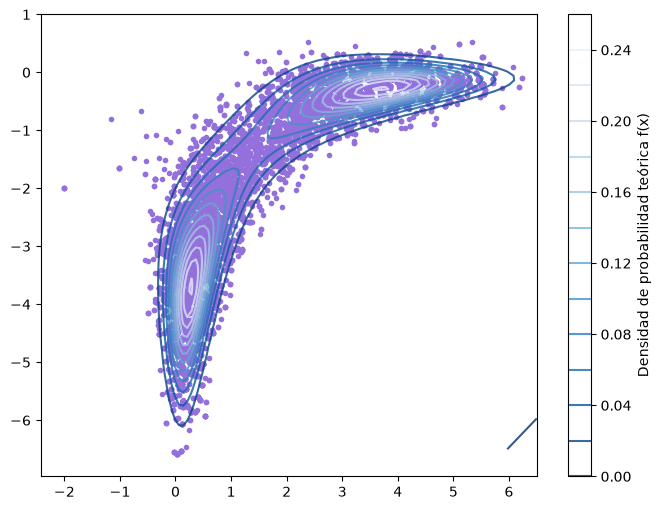

In [34]:
print("Media de X: [", mean(xt[:,0]),mean(xt[:,1]))
plt.figure(figsize=(8, 6))
plt.plot(xt[:,0],xt[:,1],'.',color='mediumpurple' )
contour = plt.contour(X0, X1, Z, levels=15, cmap='Blues_r', alpha=0.8)
plt.colorbar(contour, label='Densidad de probabilidad teórica f(x)')
plt.show()